In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os
import re
import numpy as np

# Set a professional plot style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:

task_name = "IR_title2pubmedlink" 

# --- File paths will be generated automatically based on the task name ---

# 1. Paths to the RAG results
rag_json_path = f'results/subset_accuracies_report_tasks_{task_name}.json'
rag_csv_path = f'results/final_summary_report_tasks_{task_name}.csv'

# 2. Paths to the No-RAG results
no_rag_json_path = f'results_no_rag/subset_accuracies_report_tasks_{task_name}.json'
no_rag_csv_path = f'results_no_rag/final_summary_report_tasks_{task_name}.csv'

# 3. Define the output directory for your plots
plots_dir = "thesis_visualizations"
os.makedirs(plots_dir, exist_ok=True)

print(f"Configuration set for task: {task_name}")
print(f"RAG CSV path: {rag_csv_path}")
print(f"No-RAG CSV path: {no_rag_csv_path}")

Configuration set for task: IR_title2pubmedlink
RAG CSV path: results/final_summary_report_tasks_IR_title2pubmedlink.csv
No-RAG CSV path: results_no_rag/final_summary_report_tasks_IR_title2pubmedlink.csv


In [8]:
def load_and_wrangle_all_data(rag_json_path, no_rag_json_path, rag_csv_path, no_rag_csv_path):
    """
    Loads all RAG and No-RAG result files and prepares them for visualization.
    """
    # --- 1. LOAD SUBSET JSON DATA for RAG vs. No-RAG comparison ---
    all_subset_data = []
    def process_subset_json(file_path, rag_status):
        try:
            with open(file_path, 'r') as f: data = json.load(f)
            print(f"Successfully loaded subset data from: {file_path}")
            for key, accuracies in data.items():
                if len(accuracies) > 1:
                    parts = key.split('_'); task = f"{parts[0]}_{parts[1]}"; prompt_id = parts[-2]; model_name = "_".join(parts[2:-2])
                    for acc in accuracies:
                        all_subset_data.append({"model_name": model_name, "task_name": task, "prompt_id": prompt_id, "accuracy": acc, "RAG": rag_status})
        except (FileNotFoundError, json.JSONDecodeError) as e:
            print(f"WARNING: Could not load or parse {file_path}. Error: {e}.")
    
    process_subset_json(rag_json_path, "Yes")
    process_subset_json(no_rag_json_path, "No")
    comparison_subset_df = pd.DataFrame(all_subset_data)

    # --- 2. LOAD SUMMARY CSV DATA ---
    try:
        rag_summary_df = pd.read_csv(rag_csv_path)
        no_rag_summary_df = pd.read_csv(no_rag_csv_path)
        print("Successfully loaded summary CSV files.")
        
        # Create the "best vs. best" comparison DataFrame
        best_rag_runs = rag_summary_df.loc[rag_summary_df.groupby('model_name')['overall_accuracy_%'].idxmax()]
        best_no_rag_runs = no_rag_summary_df.loc[no_rag_summary_df.groupby('model_name')['overall_accuracy_%'].idxmax()]
        comparison_summary_df = pd.concat([best_rag_runs, best_no_rag_runs], ignore_index=True)
    except FileNotFoundError as e:
        print(f"WARNING: Could not load summary CSV files. Error: {e}.")
        rag_summary_df, no_rag_summary_df, comparison_summary_df = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
        
    return comparison_subset_df, comparison_summary_df, rag_summary_df, no_rag_summary_df

# Load all data
comparison_subset_df, comparison_summary_df, rag_summary_df, no_rag_summary_df = load_and_wrangle_all_data(
    rag_json_path, no_rag_json_path, rag_csv_path, no_rag_csv_path
)

# Display the head of the processed DataFrames
#print("\n--- Combined Tidy Subset Data ---"); print(comparison_subset_df.head())
#print("\n--- Best-of Summary Comparison Data ---"); print(comparison_summary_df.head())

Successfully loaded subset data from: results/subset_accuracies_report_tasks_IR_title2pubmedlink.json
Successfully loaded subset data from: results_no_rag/subset_accuracies_report_tasks_IR_title2pubmedlink.json
Successfully loaded summary CSV files.


--- Generating Section 1: RAG vs. No-RAG Comparison Plots ---
Saved plot to: thesis_visualizations/A_distribution_comparison_IR_title2pubmedlink.png


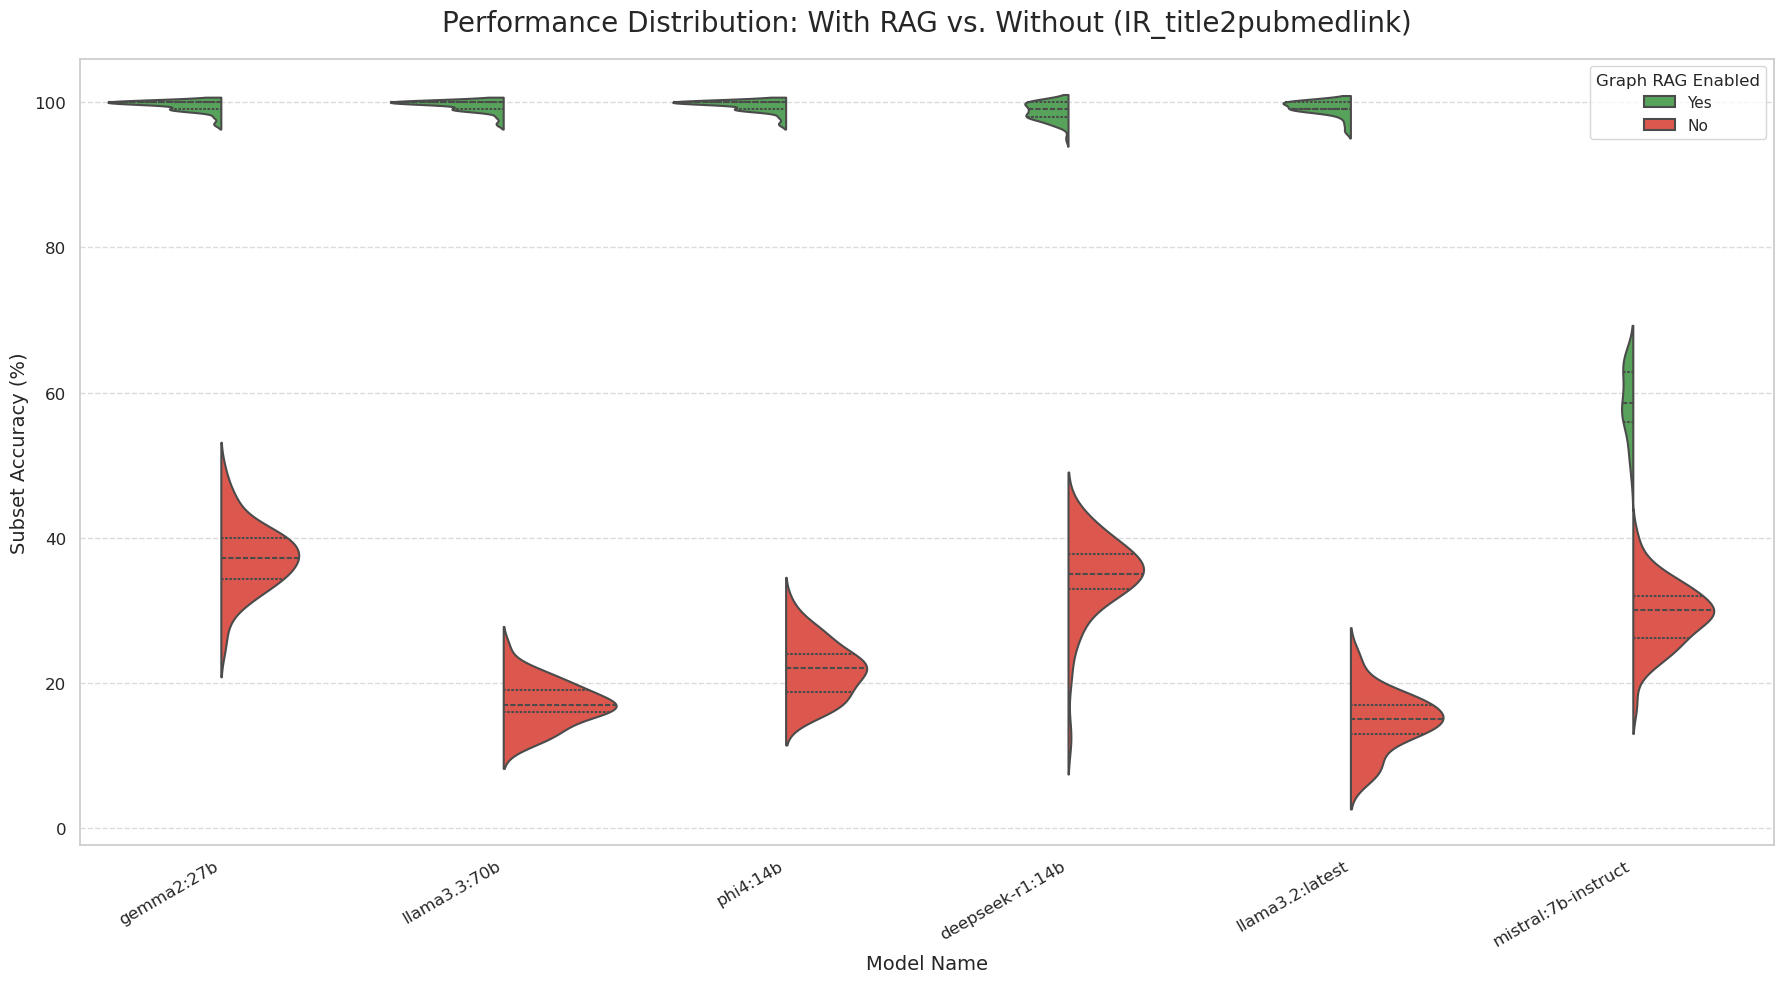

Saved plot to: thesis_visualizations/B_performance_lift_IR_title2pubmedlink.png


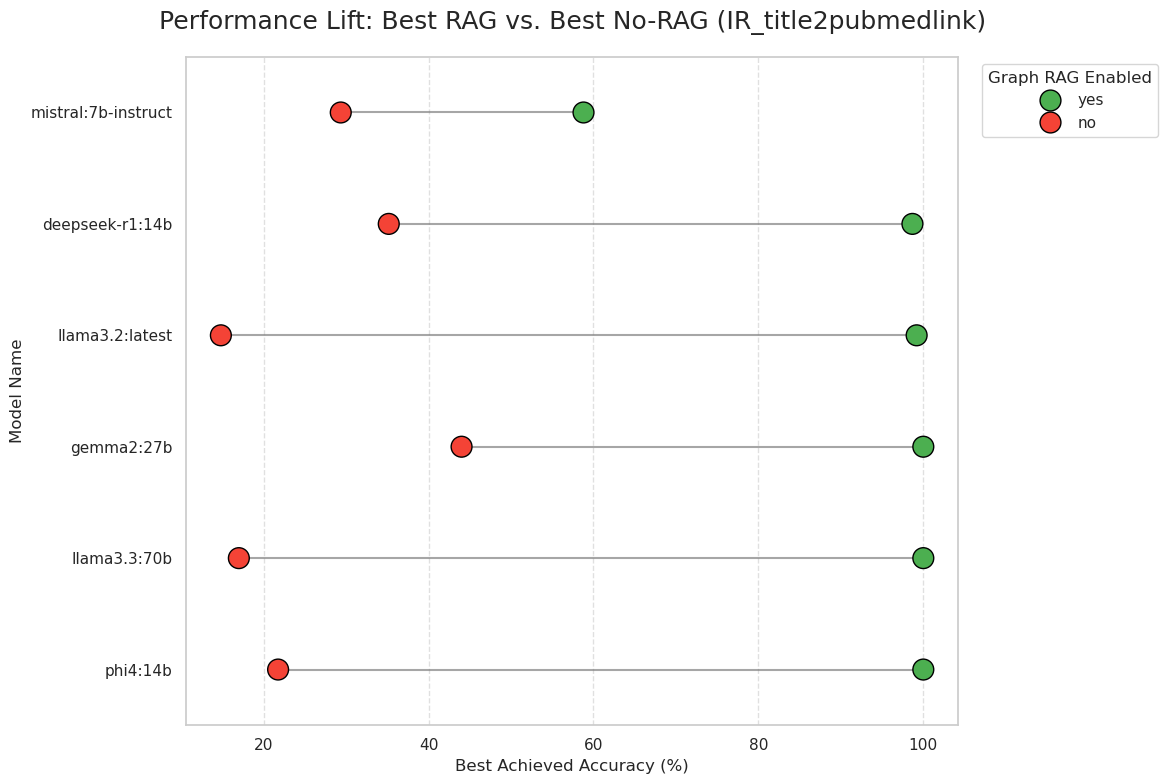

In [9]:
print("--- Generating Section 1: RAG vs. No-RAG Comparison Plots ---")

# === PLOT 1A: SPLIT VIOLIN PLOT - Comparing Full Distributions ===
if not comparison_subset_df.empty:
    median_rag_accuracies = comparison_subset_df[comparison_subset_df['RAG'] == 'Yes'].groupby('model_name')['accuracy'].median().sort_values(ascending=False)
    sorted_order = median_rag_accuracies.index
    plt.figure(figsize=(18, 10))
    sns.violinplot(
        data=comparison_subset_df, x='model_name', y='accuracy', hue='RAG',
        order=sorted_order, split=True, inner='quartile',
        palette={'Yes': '#4CAF50', 'No': '#F44336'}, linewidth=1.5
    )
    plt.title(f'Performance Distribution: With RAG vs. Without ({task_name})', fontsize=20, pad=20)
    plt.xlabel('Model Name', fontsize=14); plt.ylabel('Subset Accuracy (%)', fontsize=14)
    plt.xticks(rotation=30, ha='right', fontsize=12); plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7); plt.legend(title='Graph RAG Enabled', loc='upper right')
    plt.tight_layout()
    plot_path = os.path.join(plots_dir, f"A_distribution_comparison_{task_name}.png")
    plt.savefig(plot_path); print(f"Saved plot to: {plot_path}"); plt.show(); plt.close()
else:
    print("Subset data is empty. Skipping distribution plot.")

# === PLOT 1B: DUMBBELL PLOT - Visualizing Performance Lift ===
if not comparison_summary_df.empty:
    plt.figure(figsize=(14, 8))
    sorted_models = comparison_summary_df[comparison_summary_df['kg_rag'] == 'yes'].sort_values('overall_accuracy_%', ascending=True)['model_name']
    for model in sorted_models:
        model_data = comparison_summary_df[comparison_summary_df['model_name'] == model]
        if len(model_data) == 2:
            no_rag_acc = model_data[model_data['kg_rag'] == 'no']['overall_accuracy_%'].values[0]
            rag_acc = model_data[model_data['kg_rag'] == 'yes']['overall_accuracy_%'].values[0]
            plt.plot([no_rag_acc, rag_acc], [model, model], 'o-', color='grey', alpha=0.7, markersize=0, zorder=1)
    sns.stripplot(
        data=comparison_summary_df, x='overall_accuracy_%', y='model_name', hue='kg_rag',
        order=sorted_models, palette={'yes': '#4CAF50', 'no': '#F44336'},
        size=15, edgecolor='black', linewidth=1, jitter=0, zorder=2
    )
    plt.title(f'Performance Lift: Best RAG vs. Best No-RAG ({task_name})', fontsize=18, pad=20)
    plt.xlabel('Best Achieved Accuracy (%)', fontsize=12); plt.ylabel('Model Name', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.legend(title='Graph RAG Enabled', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plot_path = os.path.join(plots_dir, f"B_performance_lift_{task_name}.png")
    plt.savefig(plot_path); print(f"Saved plot to: {plot_path}"); plt.show(); plt.close()
else:
    print("Summary data is empty. Skipping performance lift plot.")


--- Generating Section 2: Deep Dive into RAG Performance ---


/tmp/ipykernel_954262/2668508760.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(data=full_runs_df_sorted, x='overall_accuracy_%', y='run_id', palette='plasma')


Saved RAG Bar Chart to: thesis_visualizations/C_RAG_final_performance_IR_title2pubmedlink.png


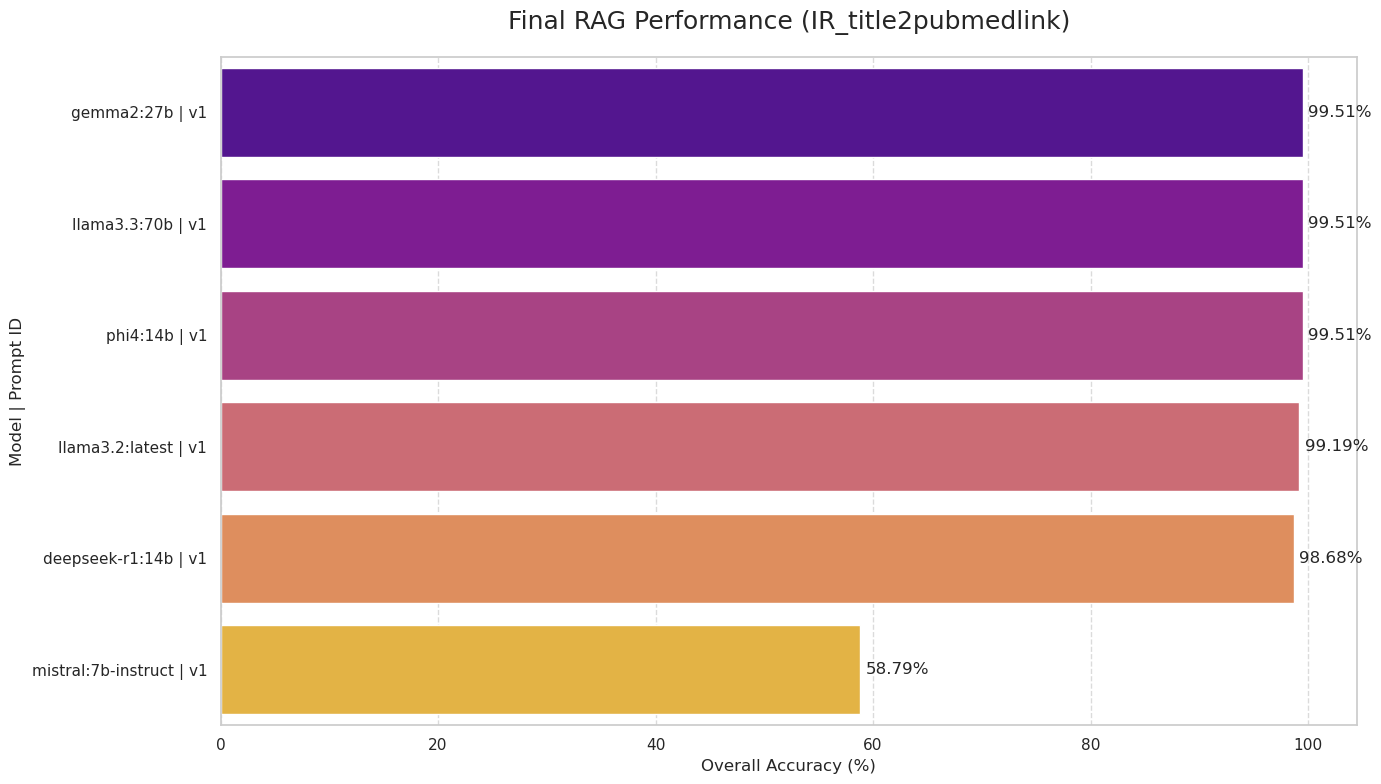

Saved RAG Heatmap to: thesis_visualizations/D_RAG_prompt_heatmap_IR_title2pubmedlink.png


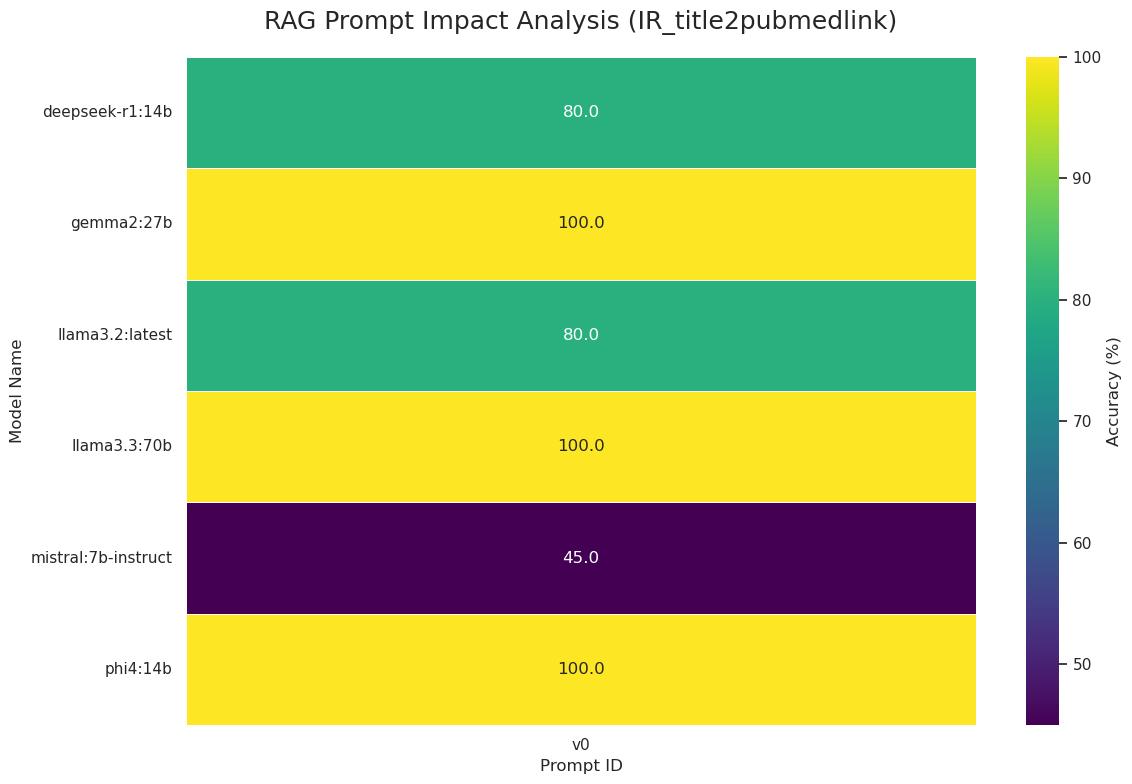


Saved RAG Scatter Plot to: thesis_visualizations/E_RAG_consistency_scatter_IR_title2pubmedlink.png


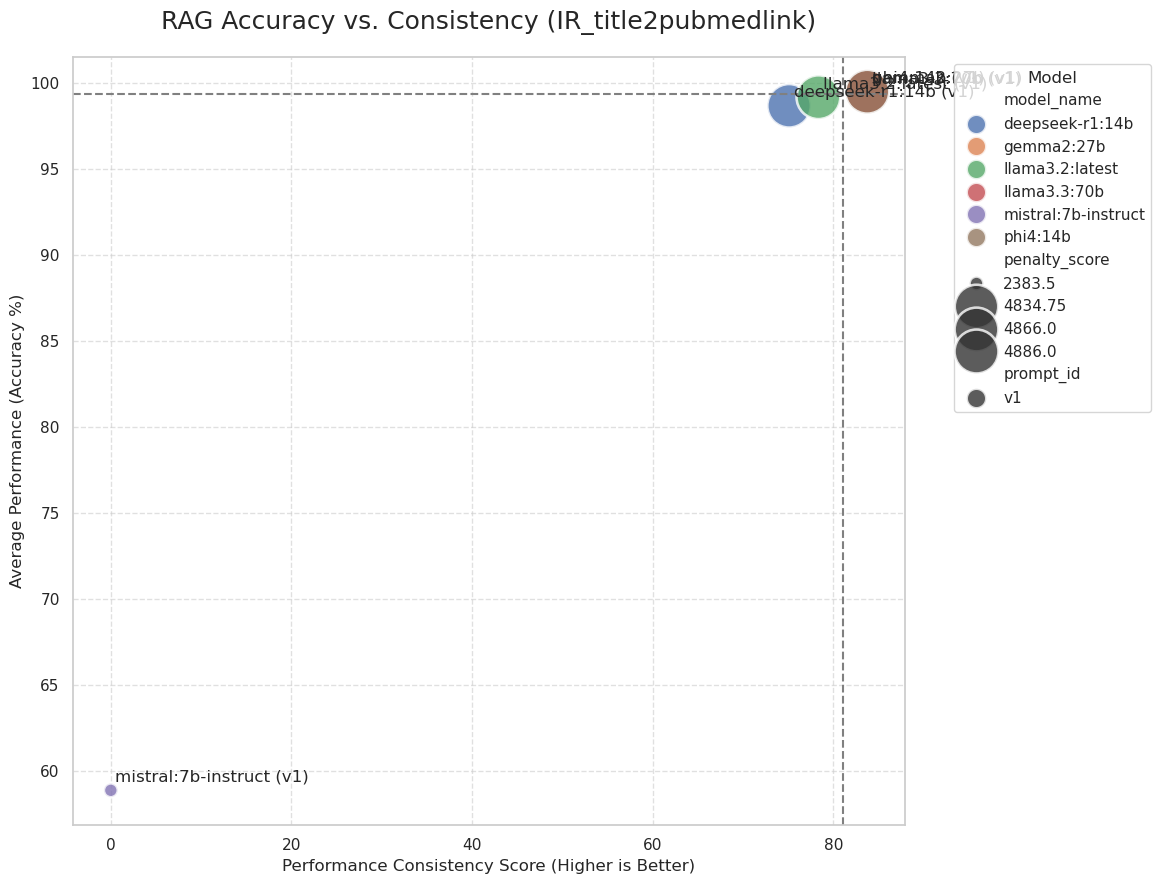

In [10]:
print("\n--- Generating Section 2: Deep Dive into RAG Performance ---")
if not rag_summary_df.empty:
    full_runs_df = rag_summary_df[rag_summary_df['total_samples'] > 101].copy()
    prompt_runs_df = rag_summary_df[rag_summary_df['total_samples'] <= 101].copy()
    
    # Plot 2A: Main Performance Bar Chart (Full Runs)
    if not full_runs_df.empty:
        full_runs_df['run_id'] = full_runs_df['model_name'] + ' | ' + full_runs_df['prompt_id']
        full_runs_df_sorted = full_runs_df.sort_values('overall_accuracy_%', ascending=False)
        plt.figure(figsize=(14, 8))
        # --- COLOR CHANGE: Reverted to your original 'plasma' palette ---
        bar_plot = sns.barplot(data=full_runs_df_sorted, x='overall_accuracy_%', y='run_id', palette='plasma')
        plt.title(f'Final RAG Performance ({task_name})', fontsize=18, pad=20); plt.xlabel('Overall Accuracy (%)', fontsize=12); plt.ylabel('Model | Prompt ID', fontsize=12)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        for p in bar_plot.patches:
            width = p.get_width(); plt.text(width + 0.5, p.get_y() + p.get_height() / 2, f'{width:.2f}%', va='center')
        plt.tight_layout(); plot_path = os.path.join(plots_dir, f"C_RAG_final_performance_{task_name}.png")
        plt.savefig(plot_path); print(f"Saved RAG Bar Chart to: {plot_path}"); plt.show(); plt.close()

    # Plot 2B: Prompt Engineering Heatmap (Partial Runs)
    if not prompt_runs_df.empty:
        pivot_df = prompt_runs_df.pivot(index='model_name', columns='prompt_id', values='overall_accuracy_%')
        plt.figure(figsize=(12, 8))
        # --- COLOR CHANGE: Reverted to your original 'viridis' colormap ---
        sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="viridis", linewidths=.5, cbar_kws={'label': 'Accuracy (%)'})
        plt.title(f'RAG Prompt Impact Analysis ({task_name})', fontsize=18, pad=20); plt.xlabel('Prompt ID', fontsize=12); plt.ylabel('Model Name', fontsize=12)
        plt.tight_layout(); plot_path = os.path.join(plots_dir, f"D_RAG_prompt_heatmap_{task_name}.png")
        plt.savefig(plot_path); print(f"Saved RAG Heatmap to: {plot_path}"); plt.show(); plt.close()

    # Plot 2C: Accuracy vs. Consistency Scatter Plot (Full Runs)
    if not full_runs_df.empty and 'std_dev_subset_accuracy' in full_runs_df.columns:
        
        # (The code to calculate 'consistency_score' remains the same)
        max_std_dev = full_runs_df['std_dev_subset_accuracy'].max()
        if max_std_dev > 0:
            full_runs_df['consistency_score'] = 100 * (1 - (full_runs_df['std_dev_subset_accuracy'] / max_std_dev))
        else:
            full_runs_df['consistency_score'] = 100.0

        plt.figure(figsize=(14, 9))
        
        scatter_plot = sns.scatterplot(
            data=full_runs_df,
            x='consistency_score',
            y='avg_subset_accuracy_%',
            hue='model_name',
            size='penalty_score',
            sizes=(100, 1000),
            alpha=0.8,
            palette='deep',
            style='prompt_id',
            s=200
        )
        
        # (The code to add labels for each point remains the same)
        for i in range(full_runs_df.shape[0]):
            plt.text(
                x=full_runs_df['consistency_score'].iloc[i] + 0.5,
                y=full_runs_df['avg_subset_accuracy_%'].iloc[i] + 0.5,
                s=f"{full_runs_df['model_name'].iloc[i]} ({full_runs_df['prompt_id'].iloc[i]})"
            )
            
        plt.title(f'RAG Accuracy vs. Consistency ({task_name})', fontsize=18, pad=20)
        plt.xlabel('Performance Consistency Score (Higher is Better)', fontsize=12)
        plt.ylabel('Average Performance (Accuracy %)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        
        # The median lines are helpful, so we'll keep them
        median_accuracy = full_runs_df['avg_subset_accuracy_%'].median()
        median_consistency = full_runs_df['consistency_score'].median()
        plt.axhline(y=median_accuracy, color='grey', linestyle='--')
        plt.axvline(x=median_consistency, color='grey', linestyle='--')
        
        # --- THIS IS THE FIX ---
        # 1. The two plt.text() lines for quadrant labels have been removed.
        
        # 2. The legend is explicitly placed outside the plot area to prevent overlap.
        #    `bbox_to_anchor=(1.05, 1)` places the legend's anchor point to the right of the plot.
        #    `loc='upper left'` pins the legend's top-left corner to that anchor.
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Model')
        
        # 3. The layout is adjusted to create space for the external legend.
        #    This shrinks the plot slightly to the left, ensuring the legend is not cut off.
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        # -------------------------
        
        plot_path = os.path.join(plots_dir, f"E_RAG_consistency_scatter_{task_name}.png")
        plt.savefig(plot_path)
        
        print(f"\nSaved RAG Scatter Plot to: {plot_path}")
        
        plt.show()
        plt.close()
    
else:
    print("No full dataset runs with standard deviation found. Skipping accuracy vs. consistency plot.")


--- Generating Section 3: Deep Dive into No-RAG Performance ---


/tmp/ipykernel_954262/1754312423.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(data=prompt_runs_df_sorted, x='overall_accuracy_%', y='run_id', palette='plasma')


Saved No-RAG Bar Chart to: thesis_visualizations/F_NoRAG_final_performance_IR_title2pubmedlink.png


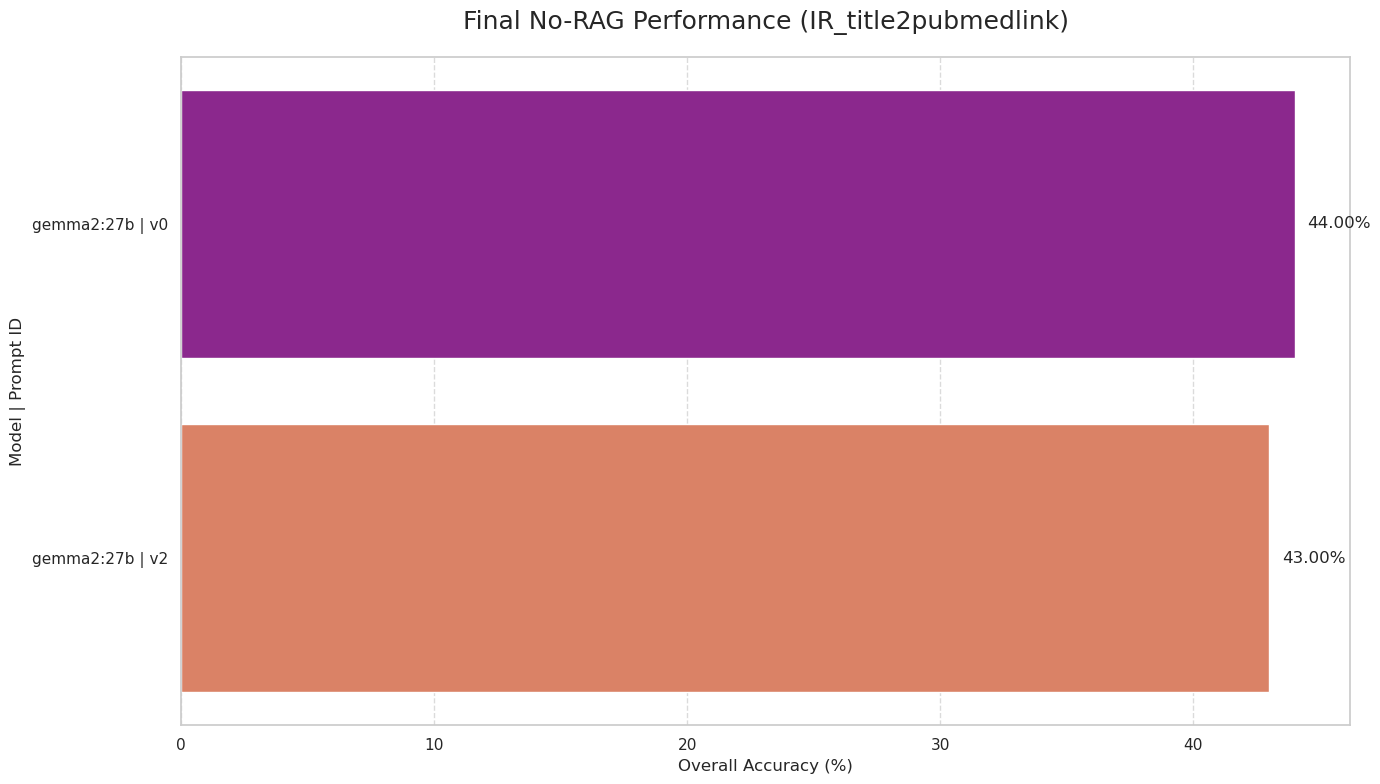

Saved No-RAG Heatmap to: thesis_visualizations/G_NoRAG_prompt_heatmap_IR_title2pubmedlink.png


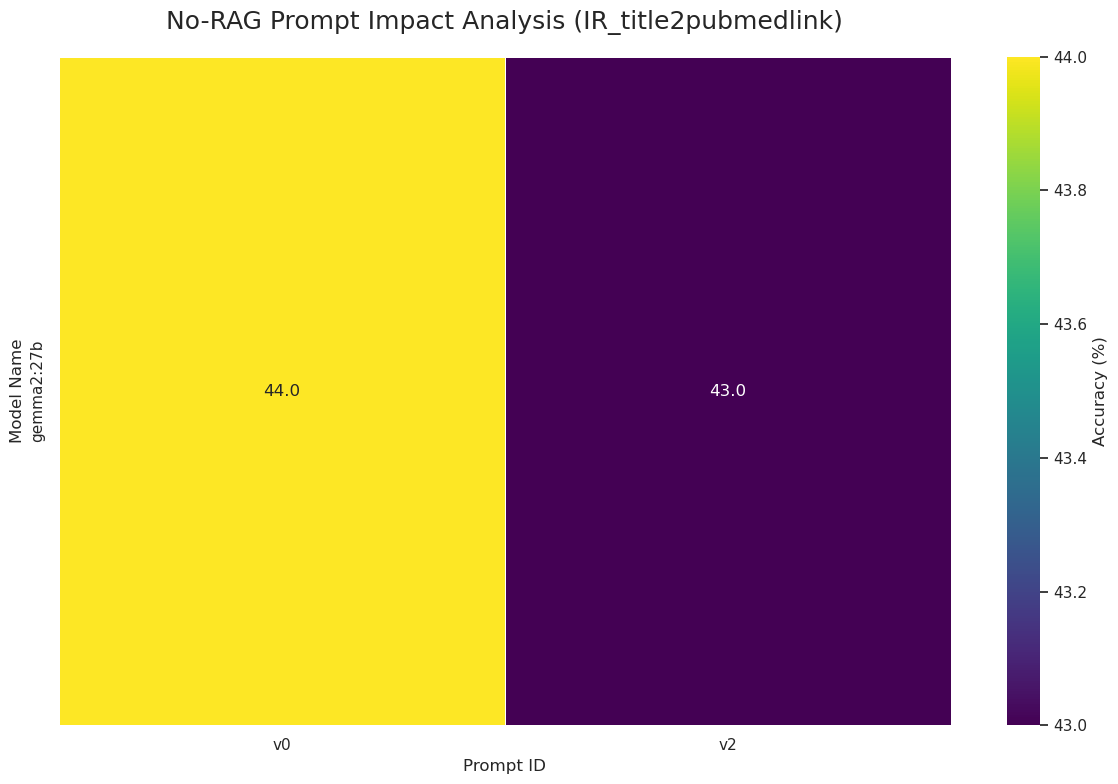


Saved RAG Scatter Plot to: thesis_visualizations/E_RAG_consistency_scatter_IR_title2pubmedlink.png


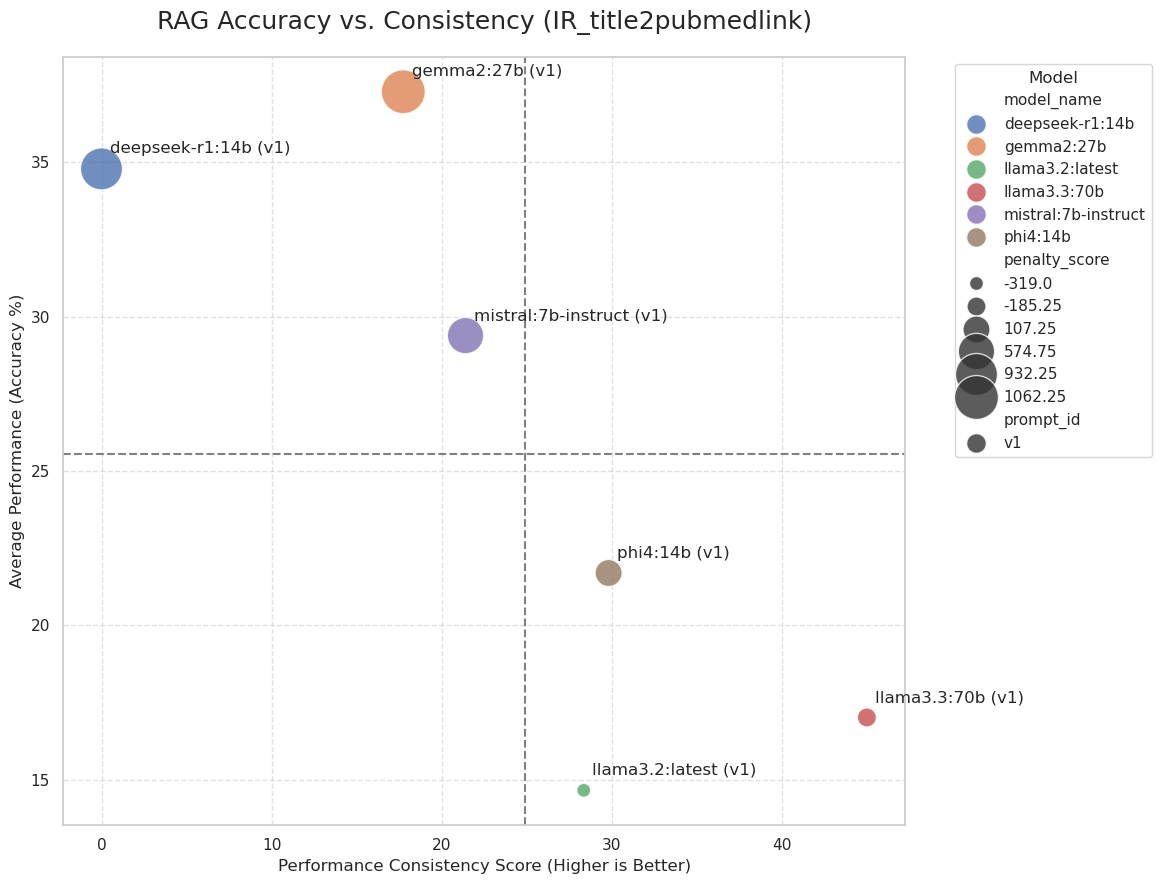

In [11]:
print("\n--- Generating Section 3: Deep Dive into No-RAG Performance ---")
if not no_rag_summary_df.empty:
    full_runs_df = no_rag_summary_df[no_rag_summary_df['total_samples'] > 101].copy()
    prompt_runs_df = no_rag_summary_df[no_rag_summary_df['total_samples'] <= 101].copy()
    
    # Plot 3A: Main Performance Bar Chart
    if not prompt_runs_df.empty: # Assuming no-rag full runs might be empty
        prompt_runs_df['run_id'] = prompt_runs_df['model_name'] + ' | ' + prompt_runs_df['prompt_id']
        prompt_runs_df_sorted = prompt_runs_df.sort_values('overall_accuracy_%', ascending=False)
        plt.figure(figsize=(14, 8))
        # --- COLOR CHANGE: Using 'plasma' for consistency ---
        bar_plot = sns.barplot(data=prompt_runs_df_sorted, x='overall_accuracy_%', y='run_id', palette='plasma')
        plt.title(f'Final No-RAG Performance ({task_name})', fontsize=18, pad=20); plt.xlabel('Overall Accuracy (%)', fontsize=12); plt.ylabel('Model | Prompt ID', fontsize=12)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        for p in bar_plot.patches:
            width = p.get_width(); plt.text(width + 0.5, p.get_y() + p.get_height() / 2, f'{width:.2f}%', va='center')
        plt.tight_layout(); plot_path = os.path.join(plots_dir, f"F_NoRAG_final_performance_{task_name}.png")
        plt.savefig(plot_path); print(f"Saved No-RAG Bar Chart to: {plot_path}"); plt.show(); plt.close()

    # Plot 3B: Prompt Engineering Heatmap
    if not prompt_runs_df.empty:
        pivot_df = prompt_runs_df.pivot(index='model_name', columns='prompt_id', values='overall_accuracy_%')
        plt.figure(figsize=(12, 8))
        # --- COLOR CHANGE: Using 'viridis' for consistency ---
        sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="viridis", linewidths=.5, cbar_kws={'label': 'Accuracy (%)'})
        plt.title(f'No-RAG Prompt Impact Analysis ({task_name})', fontsize=18, pad=20); plt.xlabel('Prompt ID', fontsize=12); plt.ylabel('Model Name', fontsize=12)
        plt.tight_layout(); plot_path = os.path.join(plots_dir, f"G_NoRAG_prompt_heatmap_{task_name}.png")
        plt.savefig(plot_path); print(f"Saved No-RAG Heatmap to: {plot_path}"); plt.show(); plt.close()

    # Plot 3C: Accuracy vs. Consistency Scatter Plot
    if not full_runs_df.empty and 'std_dev_subset_accuracy' in full_runs_df.columns:
    
        # (The code to calculate 'consistency_score' remains the same)
        max_std_dev = full_runs_df['std_dev_subset_accuracy'].max()
        if max_std_dev > 0:
            full_runs_df['consistency_score'] = 100 * (1 - (full_runs_df['std_dev_subset_accuracy'] / max_std_dev))
        else:
            full_runs_df['consistency_score'] = 100.0

        plt.figure(figsize=(14, 9))
        
        scatter_plot = sns.scatterplot(
            data=full_runs_df,
            x='consistency_score',
            y='avg_subset_accuracy_%',
            hue='model_name',
            size='penalty_score',
            sizes=(100, 1000),
            alpha=0.8,
            palette='deep',
            style='prompt_id',
            s=200
        )
        
        # (The code to add labels for each point remains the same)
        for i in range(full_runs_df.shape[0]):
            plt.text(
                x=full_runs_df['consistency_score'].iloc[i] + 0.5,
                y=full_runs_df['avg_subset_accuracy_%'].iloc[i] + 0.5,
                s=f"{full_runs_df['model_name'].iloc[i]} ({full_runs_df['prompt_id'].iloc[i]})"
            )
            
        plt.title(f'RAG Accuracy vs. Consistency ({task_name})', fontsize=18, pad=20)
        plt.xlabel('Performance Consistency Score (Higher is Better)', fontsize=12)
        plt.ylabel('Average Performance (Accuracy %)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        
        # The median lines are helpful, so we'll keep them
        median_accuracy = full_runs_df['avg_subset_accuracy_%'].median()
        median_consistency = full_runs_df['consistency_score'].median()
        plt.axhline(y=median_accuracy, color='grey', linestyle='--')
        plt.axvline(x=median_consistency, color='grey', linestyle='--')
        
        # --- THIS IS THE FIX ---
        # 1. The two plt.text() lines for quadrant labels have been removed.
        
        # 2. The legend is explicitly placed outside the plot area to prevent overlap.
        #    `bbox_to_anchor=(1.05, 1)` places the legend's anchor point to the right of the plot.
        #    `loc='upper left'` pins the legend's top-left corner to that anchor.
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Model')
        
        # 3. The layout is adjusted to create space for the external legend.
        #    This shrinks the plot slightly to the left, ensuring the legend is not cut off.
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        # -------------------------
        
        plot_path = os.path.join(plots_dir, f"E_RAG_consistency_scatter_{task_name}.png")
        plt.savefig(plot_path)
        
        print(f"\nSaved RAG Scatter Plot to: {plot_path}")
        
        plt.show()
        plt.close()
        
else:
    print("No full dataset runs with standard deviation found. Skipping accuracy vs. consistency plot.")